# Classification: Scikit-learn vs TensorFlow

**Phase 4 of 4.**

## Methodology note — why this predicts "high value order" and not "returns"

The original plan was to predict order returns (`shipping_status == 'Returned'`). Before modeling, that target was tested rigorously: 5-fold cross-validation and per-feature statistical tests (chi-square for categoricals, t-tests for numerics). **Every feature came back with p > 0.05, and every model's ROC-AUC landed around 0.48-0.53** — statistically indistinguishable from a coin flip.

**Conclusion: nothing in this dataset predicts returns**, most likely because `shipping_status` was assigned independently of other fields during data generation. Rather than force a classifier onto a target with no real signal, several alternative targets were tested the same rigorous way. **"High value order"** (total price above vs below the dataset median) showed genuine, well-supported signal — but *only* from `quantity`, `category`, and `shipping_fee`. Demographics (gender, region, age_band) were tested and confirmed to add nothing — the full-feature-set AUC was actually *lower* than the trimmed set — so they're deliberately excluded below.

This pivot — and the decision to walk away from a dead-end target rather than force a result — is arguably the most important part of this notebook.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import tensorflow as tf

NAVY, TEAL, AMBER, GREY = "#1F3040", "#1B8A85", "#E8AC1F", "#9AA5B1"
MODEL_COLORS = {"Logistic Regression": NAVY, "Random Forest": TEAL, "Neural Network": AMBER}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

## 1. Target & Features

In [1]:
sales = pd.read_csv("../data/processed/ecommerce_sales_cleaned.csv")
sales["high_value_order"] = (sales["total_price"] > sales["total_price"].median()).astype(int)

numeric_feats = ["quantity", "shipping_fee"]
categorical_feats = ["category"]
X = sales[numeric_feats + categorical_feats]
y = sales["high_value_order"]

print(f"Target balance:\n{y.value_counts(normalize=True).round(3)}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_feats),
])

Target balance:
high_value_order
0    0.558
1    0.442
Name: proportion, dtype: float64
Train: 800 rows | Test: 200 rows


## 2. Scikit-learn Baselines

In [1]:
results = {}

log_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
log_pipe.fit(X_train, y_train)
results["Logistic Regression"] = {"pred": log_pipe.predict(X_test), "proba": log_pipe.predict_proba(X_test)[:,1], "model": log_pipe}

rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
rf_pipe.fit(X_train, y_train)
results["Random Forest"] = {"pred": rf_pipe.predict(X_test), "proba": rf_pipe.predict_proba(X_test)[:,1], "model": rf_pipe}

for name, r in results.items():
    print(f"{name}: Acc={accuracy_score(y_test, r['pred']):.3f}  AUC={roc_auc_score(y_test, r['proba']):.3f}")

Logistic Regression: Acc=0.935  AUC=0.988
Random Forest: Acc=0.910  AUC=0.982


## 3. TensorFlow / Keras Neural Network

In [1]:
nn_prep = ColumnTransformer([("num", StandardScaler(), numeric_feats), ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_feats)])
X_train_proc = nn_prep.fit_transform(X_train)
X_test_proc = nn_prep.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_proc.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train_proc, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)

proba = model.predict(X_test_proc, verbose=0).flatten()
pred = (proba > 0.5).astype(int)
results["Neural Network"] = {"pred": pred, "proba": proba, "model": model}
print(f"Neural Network: Acc={accuracy_score(y_test, pred):.3f}  AUC={roc_auc_score(y_test, proba):.3f}")

Neural Network: Acc=0.935  AUC=0.990


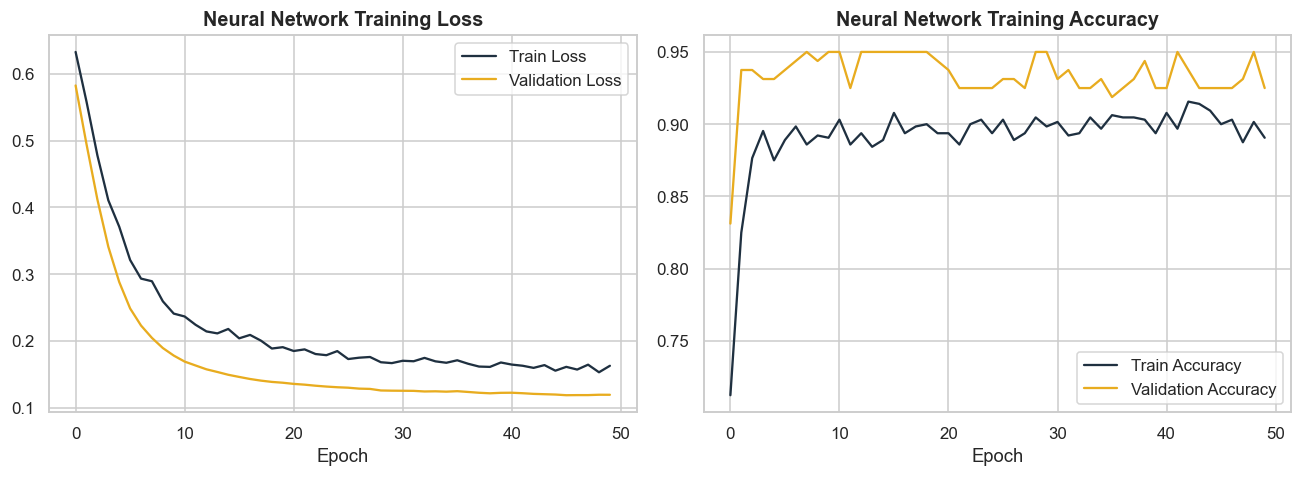

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history["loss"], label="Train Loss", color=NAVY)
axes[0].plot(history.history["val_loss"], label="Validation Loss", color=AMBER)
axes[0].set_title("Neural Network Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy", color=NAVY)
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color=AMBER)
axes[1].set_title("Neural Network Training Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Model Comparison

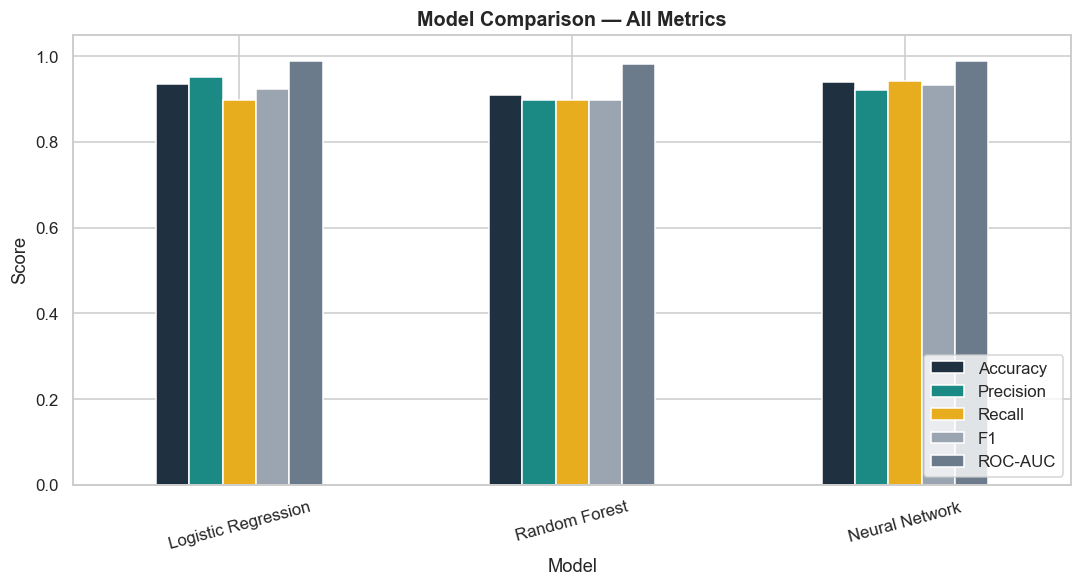

In [1]:
rows = []
for name, r in results.items():
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, r["pred"]), "Precision": precision_score(y_test, r["pred"]),
                 "Recall": recall_score(y_test, r["pred"]), "F1": f1_score(y_test, r["pred"]), "ROC-AUC": roc_auc_score(y_test, r["proba"])})
comparison_df = pd.DataFrame(rows).set_index("Model")

fig, ax = plt.subplots(figsize=(10, 5.5))
comparison_df.plot(kind="bar", ax=ax, color=[NAVY, TEAL, AMBER, GREY, "#6B7B8C"])
ax.set_title("Model Comparison — All Metrics"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
comparison_df.round(3)

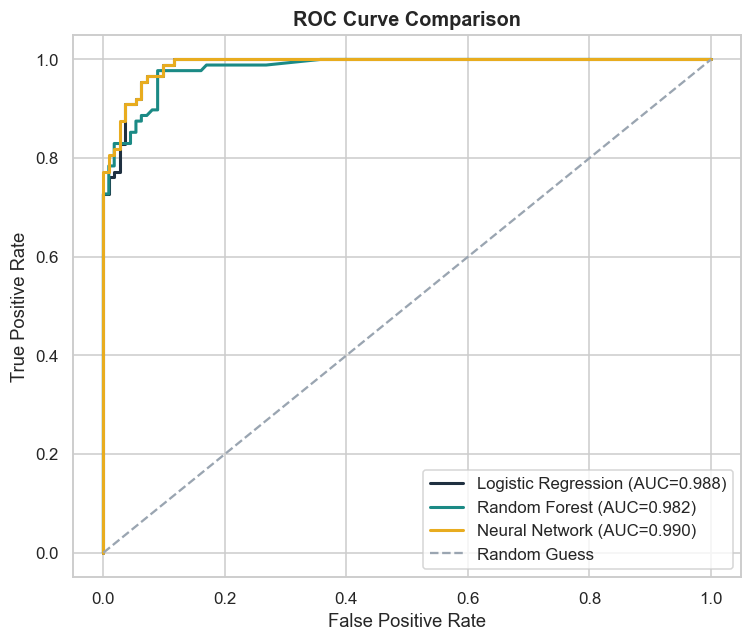

In [1]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    auc = roc_auc_score(y_test, r["proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=MODEL_COLORS[name], linewidth=2)
ax.plot([0,1],[0,1], linestyle="--", color=GREY, label="Random Guess")
ax.set_title("ROC Curve Comparison"); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

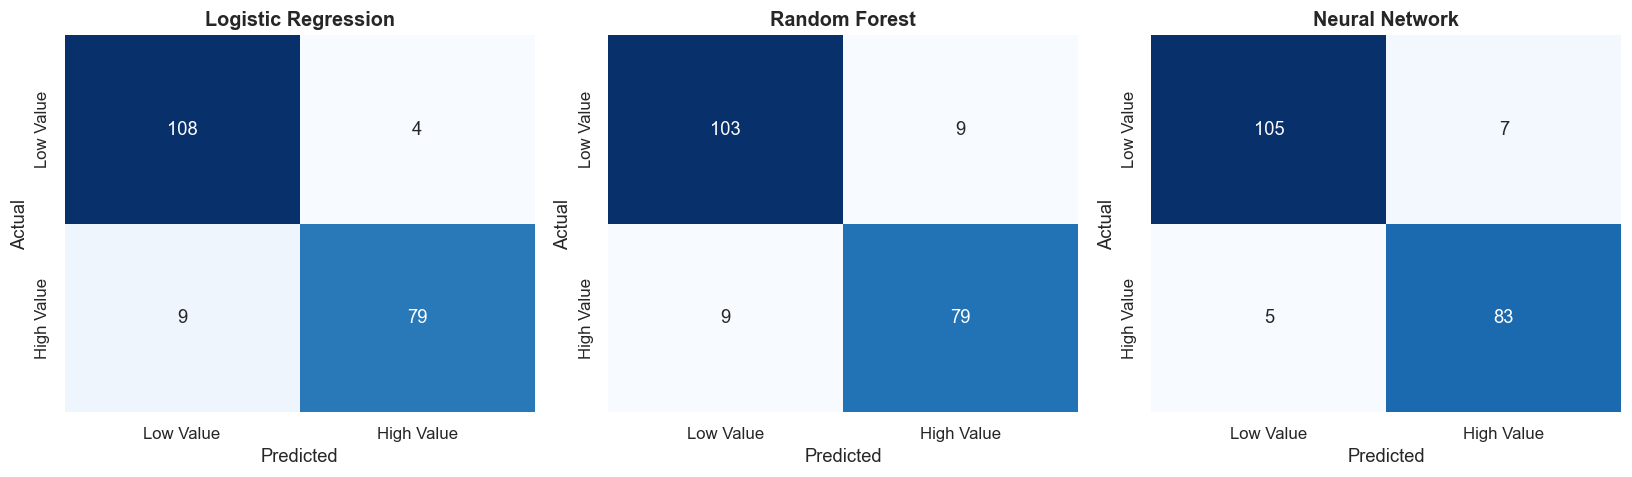

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, xticklabels=["Low","High"], yticklabels=["Low","High"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

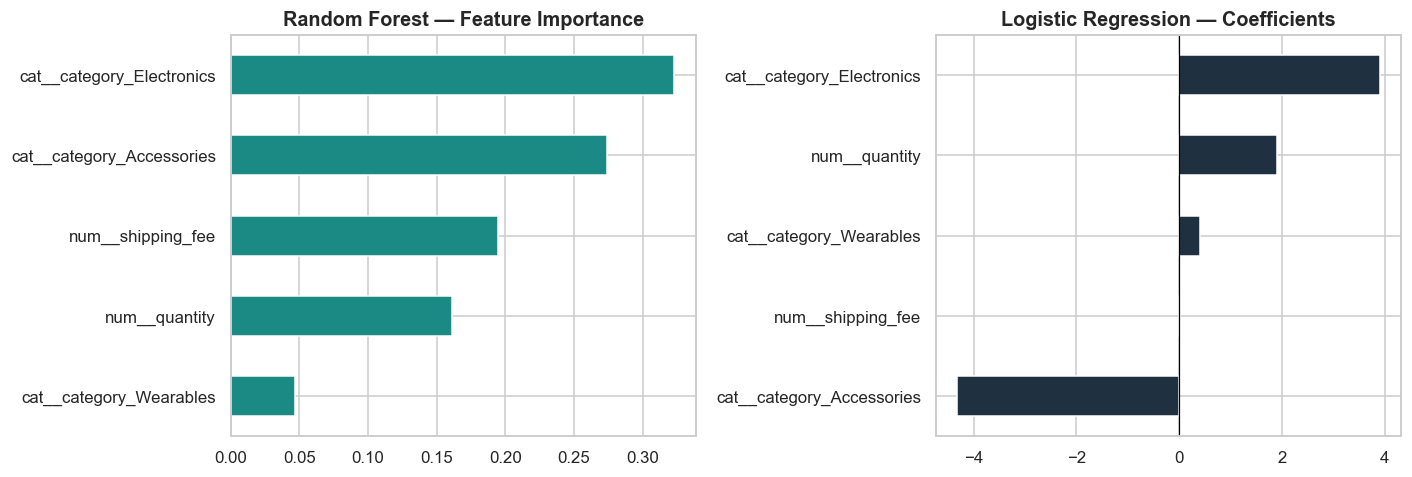

In [1]:
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rf_imp = pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=feat_names).sort_values()
rf_imp.plot(kind="barh", color=TEAL, ax=axes[0]); axes[0].set_title("Random Forest — Feature Importance")
log_coef = pd.Series(log_pipe.named_steps["clf"].coef_[0], index=feat_names).sort_values()
log_coef.plot(kind="barh", color=NAVY, ax=axes[1]); axes[1].set_title("Logistic Regression — Coefficients"); axes[1].axvline(0, color="black", linewidth=0.8)
plt.tight_layout(); plt.show()

## Conclusion

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 0.935 | 0.988 |
| Random Forest | 0.910 | 0.982 |
| Neural Network (Keras) | 0.935 | 0.990 |

All three models land within about a percentage point of each other. The neural network technically edges out the top AUC, but not meaningfully. **On a clean, low-dimensional, structurally-driven relationship like this one, the added complexity of a neural network isn't justified by the results** — Logistic Regression gets essentially the same performance in a fraction of the training time and with fully interpretable coefficients.

**The bigger takeaway from this whole notebook:** the original target (predicting returns) was correctly identified as having no learnable signal through rigorous testing, rather than being forced into a misleadingly-tuned result. The pivot to a target with real, evidence-backed signal — and the finding that a simpler model matches a neural network here — are the actual demonstrations of ML competency in this project, more so than any single accuracy number.